## Setup and Helper Functions

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ensure plots are displayed inline in Jupyter
%matplotlib inline

def show_images(images, titles, cmap='gray'):
    """
    Helper function to display multiple images side by side using Matplotlib.
    """
    plt.figure(figsize=(18, 6))
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        
        # Check if the image has 3 channels (Color) or 1 channel (Grayscale)
        if len(images[i].shape) == 3:
            # Convert BGR to RGB for correct display in Matplotlib
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(images[i], cmap=cmap)
            
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Define image path based on your directory structure
image_path = 'images/Lenna.png'

## Exercise 1 - Gaussian Filter & Noise Calculation

### Load the image and convert to grayscale

In [2]:
original_img = cv2.imread(image_path)
gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

### Add Gaussian Noise manually

In [3]:
mean = 0
sigma = 15
# Generate Gaussian noise
gauss_noise = np.random.normal(mean, sigma, gray_img.shape).astype('float64')

# Add noise to the image (Cast to float to avoid overflow during addition)
noisy_img_float = gray_img.astype('float64') + gauss_noise

# Clip values to stay within [0, 255] and convert back to uint8
noisy_img = np.clip(noisy_img_float, 0, 255).astype('uint8')

### Apply Gaussian Filter

In [4]:
# Using a 5x5 kernel as requested
filtered_img = cv2.GaussianBlur(noisy_img, (5, 5), 0)

### Calculate Residual Noise

In [5]:
# Calculate difference: (Noisy Image - Filtered Image)
residual_diff = noisy_img.astype('float64') - filtered_img.astype('float64')

# Calculate the Mean Absolute Difference
mean_residual = np.mean(np.abs(residual_diff))
print(f"Mean Residual Noise (Mean Absolute Difference): {mean_residual:.4f}")

Mean Residual Noise (Mean Absolute Difference): 11.4884


### Display Results

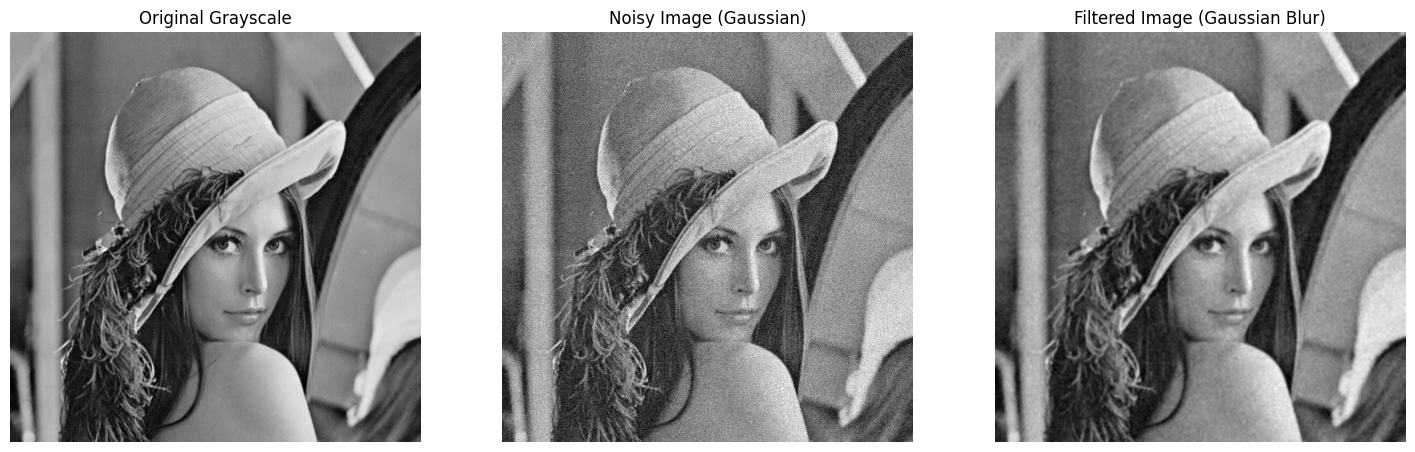

In [6]:
show_images(
    [gray_img, noisy_img, filtered_img],
    ['Original Grayscale', 'Noisy Image (Gaussian)', 'Filtered Image (Gaussian Blur)']
)

## Exercise 2 - Edge Sharpening with Sobel

### Use the grayscale image from the previous step

In [7]:
img_for_edge = gray_img.copy()

### Calculate Edges using Sobel

In [8]:
# Calculate Gradient in X direction (CV_64F handles negative slopes)
sobel_x = cv2.Sobel(img_for_edge, cv2.CV_64F, 1, 0, ksize=3)

# Calculate Gradient in Y direction
sobel_y = cv2.Sobel(img_for_edge, cv2.CV_64F, 0, 1, ksize=3)

# Calculate Combined Gradient Magnitude: sqrt(x^2 + y^2)
gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

### Normalize Gradient

In [9]:
# Normalize values to range [0, 255] for valid image display/addition
gradient_normalized = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

### Add Gradient to Original Image (Sharpening)

In [10]:
# cv2.add handles overflow (saturation) automatically
sharpened_img = cv2.add(img_for_edge, gradient_normalized)

### Display Results

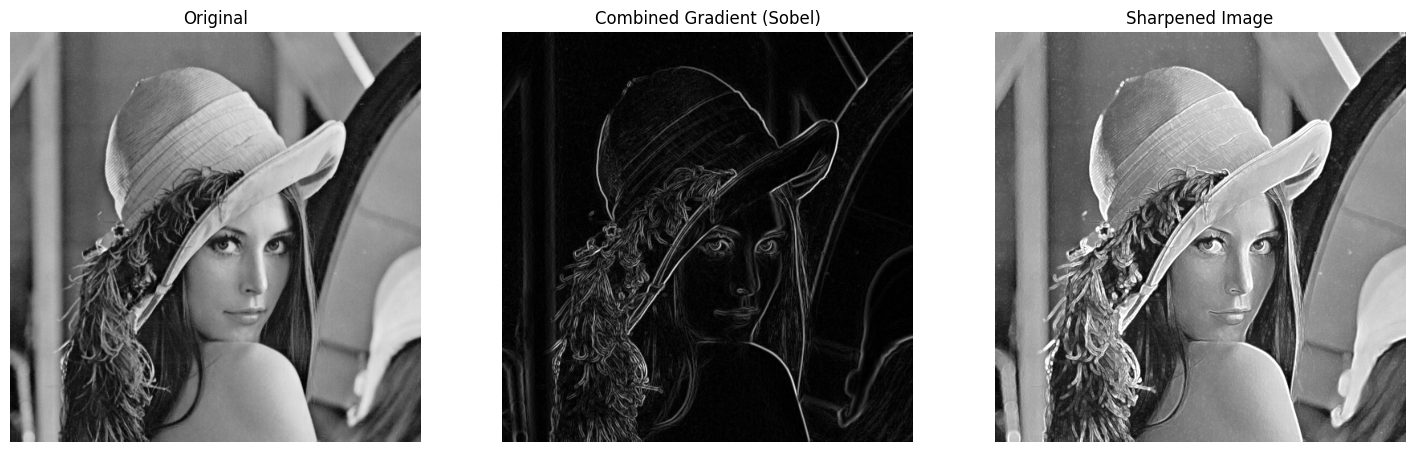

In [11]:
show_images(
    [img_for_edge, gradient_normalized, sharpened_img],
    ['Original', 'Combined Gradient (Sobel)', 'Sharpened Image']
)

## Exercise 3 - Binary Image Cleaning (Morphology)

### Load and Threshold

In [12]:
# Convert grayscale to binary image (Black & White)
_, binary_img = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)

# OPTIONAL: Add Synthetic Noise 
# Since standard images like Lenna are "clean", Morphological operations might not show 
# a visible difference. We add "Salt and Pepper" noise to demonstrate the cleaning effect.
noisy_binary = binary_img.copy()

# Add Salt noise (white dots)
num_salt = 1500
coords_salt = [np.random.randint(0, i - 1, num_salt) for i in binary_img.shape]
noisy_binary[tuple(coords_salt)] = 255

# Add Pepper noise (black dots)
num_pepper = 1500
coords_pepper = [np.random.randint(0, i - 1, num_pepper) for i in binary_img.shape]
noisy_binary[tuple(coords_pepper)] = 0

### Define Structuring Element

In [13]:
# Creating a 5x5 Rectangular kernel
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

### Apply Cleaning Operations

In [14]:
# Step A: Opening (Erosion -> Dilation) to remove small white noise (Salt)
opening = cv2.morphologyEx(noisy_binary, cv2.MORPH_OPEN, kernel)

# Step B: Closing (Dilation -> Erosion) on the result to fill small black holes (Pepper)
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

final_cleaned_img = closing

### Display Results

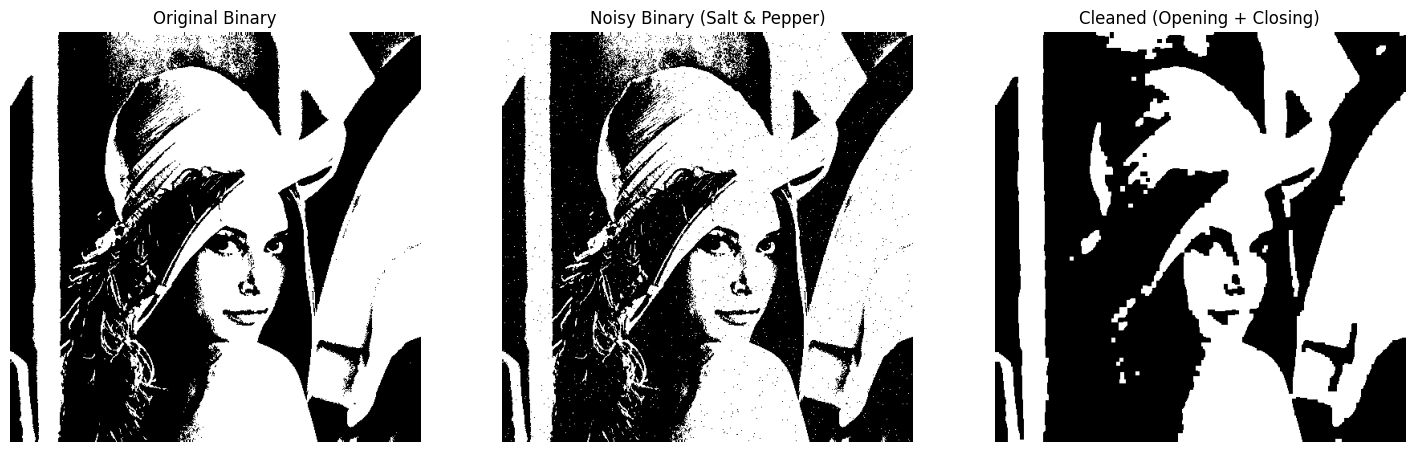

In [15]:
show_images(
    [binary_img, noisy_binary, final_cleaned_img],
    ['Original Binary', 'Noisy Binary (Salt & Pepper)', 'Cleaned (Opening + Closing)']
)